--- Primeras filas de tus datos sintéticos controlados ---
          X         Y         Z
0  0.496714 -0.815469  0.285956
1 -0.138264 -0.548911 -0.268572
2  0.647689  0.470380  0.733540
3  1.523030  1.356392  2.643077
4 -0.234153 -0.365891 -2.421831


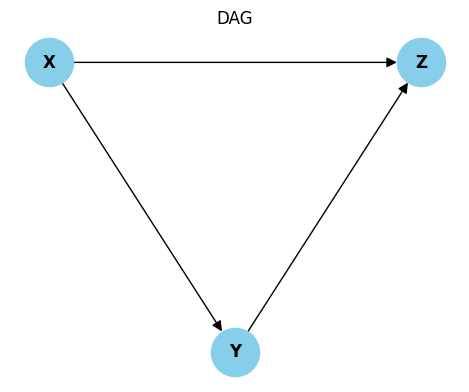

In [1]:
# ==============================================================================
# BLOQUE 1: GENERACIÓN DE DATOS SINTÉTICOS PARA EL TRIÁNGULO NO LINEAL
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import time
import re
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed

# 1. Definición del Grafo (X -> Y -> Z y X -> Z)
graph_triangle = nx.DiGraph([
    ('X', 'Y'),
    ('X', 'Z'),
    ('Y', 'Z')
])

# 2. Generación del SCM No Lineal Verdadero
def generate_synthetic_triangle_data(num_samples=2000, seed=42):
    np.random.seed(seed)
    
    # RUIDO GAUSIANO
    eps_X = np.random.normal(0, 1.0, num_samples)
    eps_Y = np.random.normal(0, 1.0, num_samples)
    eps_Z = np.random.normal(0, 1.0, num_samples)
    
    # Ecuaciones del SCM
    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z
    
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

# Crear el DataFrame sintético limpio
data_triangle = generate_synthetic_triangle_data(num_samples=100)

print("--- Primeras filas de tus datos sintéticos controlados ---")
print(data_triangle.head())

# 3. Partición de datos (50% Train / 50% Eval) y Normalización
factual_train_d, factual_eval_d = train_test_split(data_triangle, test_size=0.5, random_state=42)

# Mapeo de tipos requerido por la arquitectura kan_model_mixed
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {} # Todo es puramente continuo

# Pintar el grafo estructural 
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG")
plt.show()

In [2]:
# ==============================================================================
# BLOQUE 2: ENTRENAMIENTO MULTI-ESTRATEGIA EXCLUSIVO CON DATOS DE TRAIN
# ==============================================================================

# 1. Generación de la rejilla de pesos (11 puntos entre 0.0 y 1.0)
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)

# Hiperparámetros base globales de la red KAN
base_kan_params = {
    'hidden_dim': 5,
    'batch_size': -1,     # Batch completo para estabilizar estimaciones del HSIC conjunto
    'grid': 5,
    'k': 5,
    'seed': 42,
    'lr': 0.002,
    'early_stop': True,
    'steps': 5000,
    'lamb': 0.05,
    'lamb_entropy': 0.05,
    'sparse_init': False,
    'mult_kan': True,
    'try_gpu': False,
    'verbose': 0
}

# Estructuras de datos para almacenar los resultados en la memoria RAM
baselines = ['mse', 'hsic']
trained_models = {}
times_log = {}
training_history = {}  # strategy/config -> {nodo: dict devuelto por kan_predictor.fit()}

# Función auxiliar para empaquetar la configuración anidada por nodo que exige kan_model_mixed
def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta):
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

# Si model.fit() devuelve None (en vez de un dict por nodo), el kernel está
# ejecutando una versión vieja de kan_model_mixed.fit cacheada en memoria:
# reinicia el kernel (Kernel > Restart) y vuelve a ejecutar desde el Bloque 1.
def _validar_resultado_fit(resultado, etiqueta):
    if resultado is None:
        raise RuntimeError(
            f"model.fit(...) devolvió None para '{etiqueta}'. "
            "Esto indica que el kernel tiene cargada una versión antigua de "
            "kan_model_mixed.fit (de antes de que devolviera resultados). "
            "Reinicia el kernel (Kernel > Restart) y vuelve a ejecutar el notebook "
            "desde el Bloque 1 antes de continuar."
        )
    return resultado

# --- PARTE A: ENTRENAMIENTO DE LÍNEAS BASE PURAS ---
for strategy in baselines:
    print(f"Entrenando KAN Estrategia Pura: {strategy.upper()}...")
    alpha_val, beta_val = (1.0, 0.0) if strategy == "mse" else (0.0, 1.0)
    
    params_estructurados = crear_estructura_nodos(
        graph_triangle, base_kan_params, strategy, alpha_val, beta_val
    )
    
    model = kan_model_mixed(graph_triangle, params_estructurados)
    
    t_start = time.time()
    # VALIDACIÓN: Entrenamos únicamente con el conjunto de TRAIN
    # El modelo calculará internamente el HSIC conjunto usando /models/kan.py
    resultados_entrenamiento = _validar_resultado_fit(model.fit(data=factual_train_d), strategy)
    elapsed = time.time() - t_start
    
    # Guardado en memoria
    trained_models[strategy] = model
    times_log[strategy] = elapsed
    training_history[strategy] = resultados_entrenamiento
    print(f"   -> Completado en {elapsed:.2f} segundos.")

# --- PARTE B: ENTRENAMIENTO DEL GRID SEARCH HÍBRIDO ---
print("\nIniciando Grid Search para la estrategia HYBRID...")
for alpha in valores_alpha_candidatos:
    beta = 1.0 - alpha
    alpha = round(alpha, 2)
    beta = round(beta, 2)
    
    # Evitamos duplicar los extremos ya entrenados en las líneas base
    if alpha == 1.0 or alpha == 0.0:
        continue
        
    model_key = f"hybrid_alpha{alpha}_beta{beta}"
    print(f"Entrenando KAN HYBRID -> Configuración: Alpha={alpha} | Beta={beta}")
    
    params_estructurados = crear_estructura_nodos(
        graph_triangle, base_kan_params, 'hybrid', alpha, beta
    )
    
    model = kan_model_mixed(graph_triangle, params_estructurados)
    
    t_start = time.time()
    # VALIDACIÓN: Entrenamos únicamente con el conjunto de TRAIN
    resultados_entrenamiento_hibrido = _validar_resultado_fit(model.fit(data=factual_train_d), model_key)
    elapsed = time.time() - t_start
    
    # Guardado en memoria
    trained_models[model_key] = model
    times_log[model_key] = elapsed
    training_history[model_key] = resultados_entrenamiento_hibrido
    print(f"   -> Completado en {elapsed:.2f} segundos.")

print("\n¡Entrenamiento finalizado! Todos los modelos guardados y listos para evaluación en testing.")

Entrenando KAN Estrategia Pura: MSE...
Using device: cpu
Early stopping at step 45
Using device: cpu
Early stopping at step 97
   -> Completado en 2.75 segundos.
Entrenando KAN Estrategia Pura: HSIC...
Using device: cpu
Early stopping at step 216
Using device: cpu
Early stopping at step 180
   -> Completado en 4.92 segundos.

Iniciando Grid Search para la estrategia HYBRID...
Entrenando KAN HYBRID -> Configuración: Alpha=0.1 | Beta=0.9
Using device: cpu
Early stopping at step 76
Using device: cpu
Early stopping at step 95
   -> Completado en 2.54 segundos.
Entrenando KAN HYBRID -> Configuración: Alpha=0.2 | Beta=0.8
Using device: cpu
Early stopping at step 75
Using device: cpu
Early stopping at step 97
   -> Completado en 2.08 segundos.
Entrenando KAN HYBRID -> Configuración: Alpha=0.3 | Beta=0.7
Using device: cpu
Early stopping at step 50
Using device: cpu
Early stopping at step 98
   -> Completado en 1.89 segundos.
Entrenando KAN HYBRID -> Configuración: Alpha=0.4 | Beta=0.6
Using de

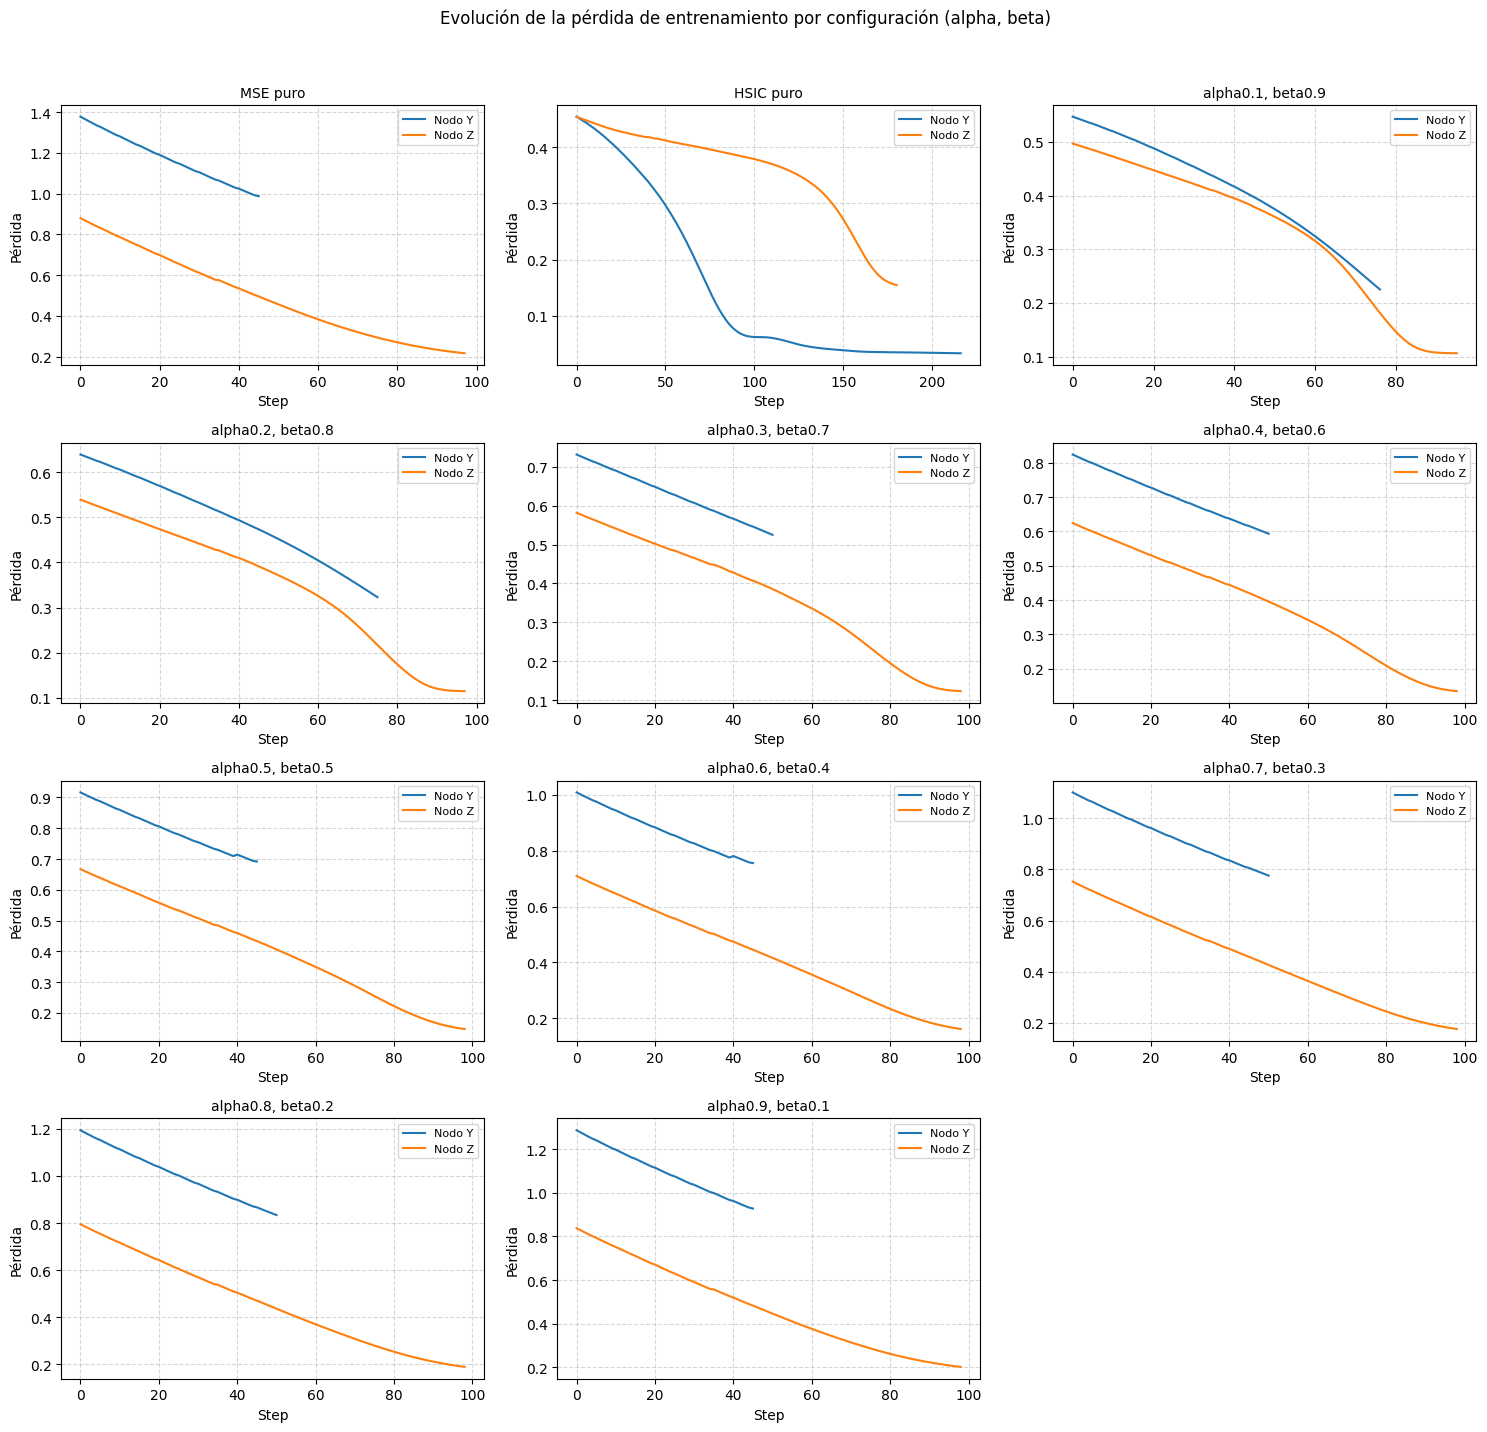

In [3]:
# ==============================================================================
# BLOQUE 2B: EVOLUCIÓN DE LA PÉRDIDA DE ENTRENAMIENTO POR CONFIGURACIÓN (train_loss_all)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import math


def _a_valor(x):
    """Convierte un tensor de torch (o escalar) a float plano."""
    if hasattr(x, 'detach'):
        x = x.detach()
    if hasattr(x, 'cpu'):
        x = x.cpu()
    return float(np.asarray(x))


def plot_train_loss_por_configuracion(training_history, nodos=('Y', 'Z'), n_cols=3):
    """Una gráfica por cada combinación alpha/beta entrenada en el Bloque 2
    (mse, hsic, hybrid_*): eje X = step de entrenamiento, eje Y = valor de la
    función de pérdida (train_loss_all / lista_loss)."""
    configs = list(training_history.keys())
    hybrids = sorted(c for c in configs if c.startswith('hybrid'))
    orden = [c for c in ['mse', 'hsic'] if c in configs] + hybrids

    n = len(orden)
    n_cols = min(n_cols, n)
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=False)
    colores = {'Y': 'tab:blue', 'Z': 'tab:orange'}

    for i, config in enumerate(orden):
        ax = axes[i // n_cols][i % n_cols]
        for nodo in nodos:
            resultado_nodo = training_history.get(config, {}).get(nodo)
            if resultado_nodo is None or 'lista_loss' not in resultado_nodo:
                continue
            curva = [_a_valor(v) for v in resultado_nodo['lista_loss']]
            if not curva:
                continue
            ax.plot(range(len(curva)), curva, label=f"Nodo {nodo}", color=colores.get(nodo))

        if config == 'mse':
            titulo = 'MSE puro'
        elif config == 'hsic':
            titulo = 'HSIC puro'
        else:
            titulo = config.replace('hybrid_', '').replace('_', ', ')
        ax.set_title(titulo, fontsize=10)
        ax.set_xlabel("Step")
        ax.set_ylabel("Pérdida")
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)

    # Ocultar subplots sobrantes si el grid no se llena del todo
    for j in range(n, n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis('off')

    plt.suptitle("Evolución de la pérdida de entrenamiento por configuración (alpha, beta)", y=1.02)
    plt.tight_layout()
    plt.show()


plot_train_loss_por_configuracion(training_history)

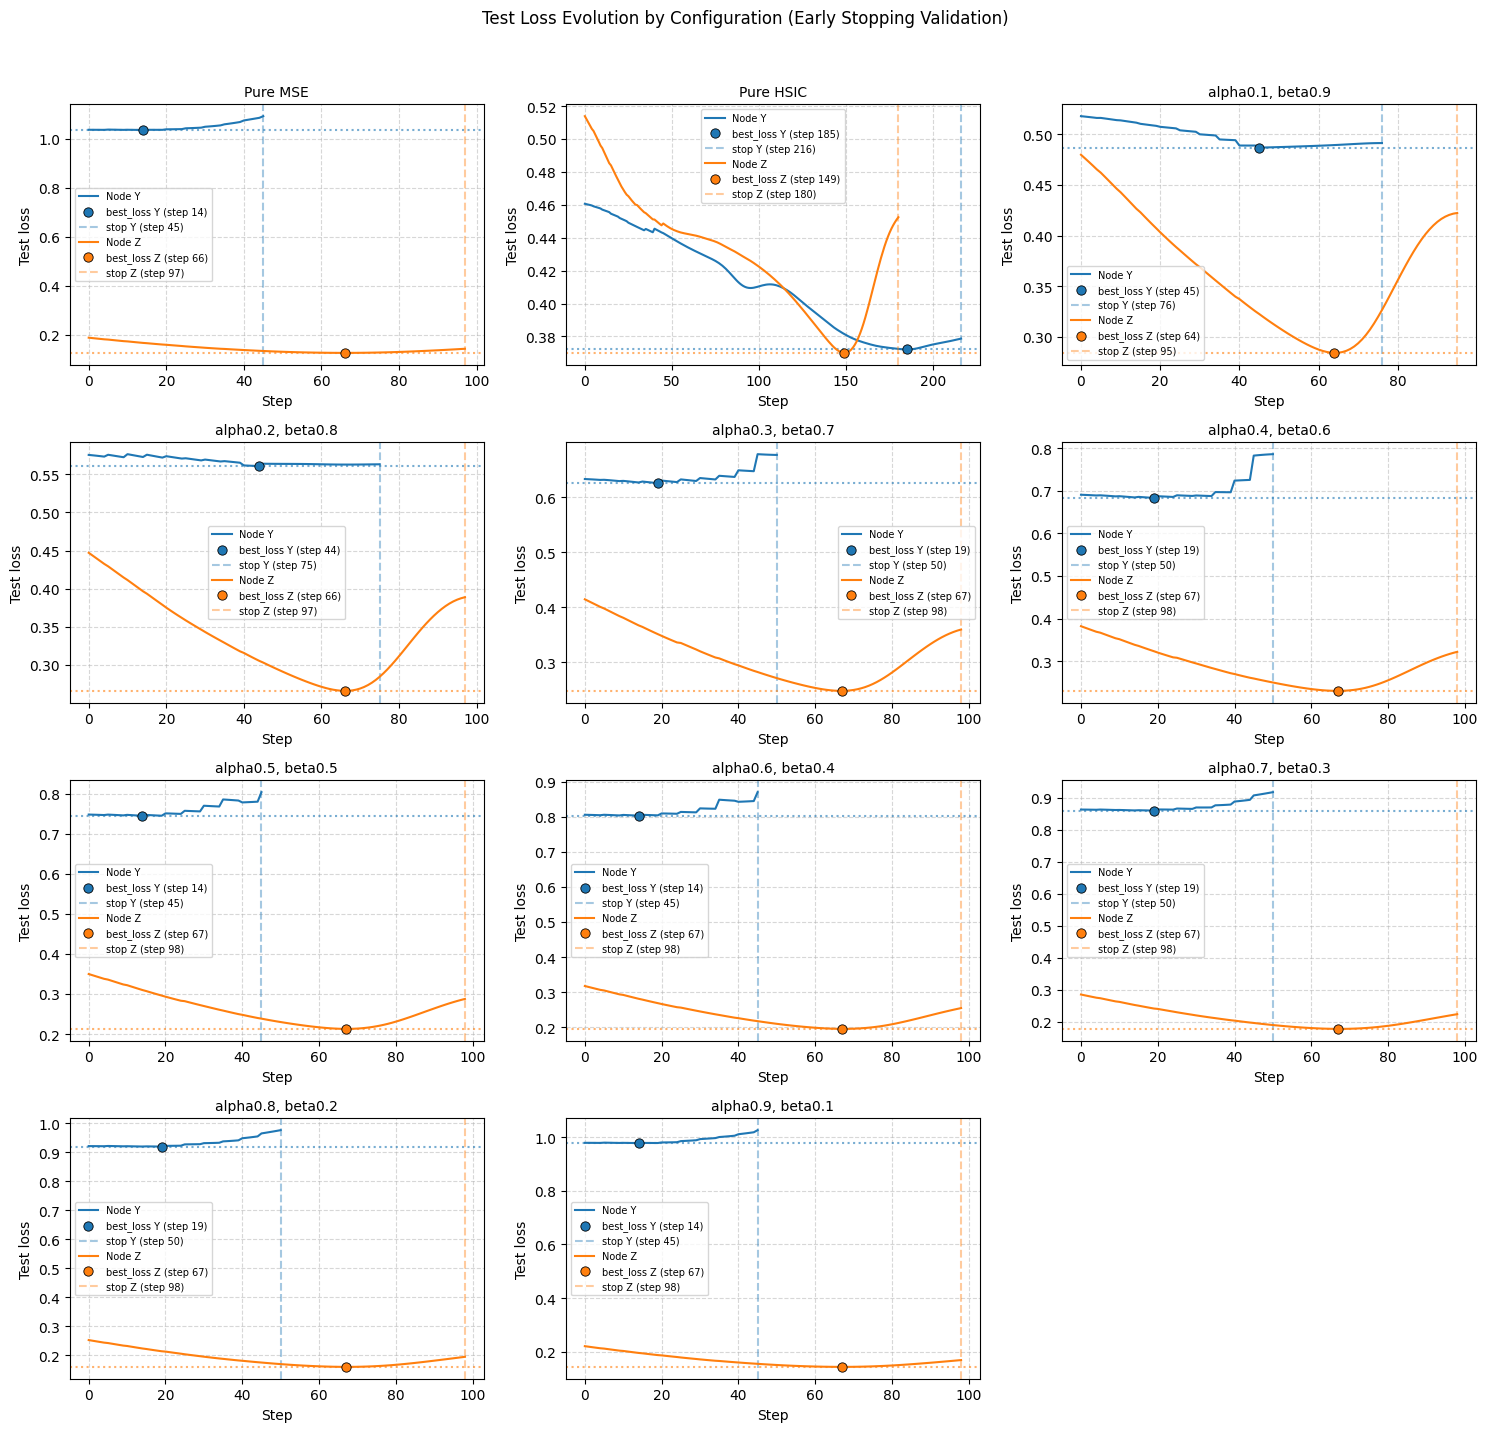

In [4]:
# ==============================================================================
# BLOQUE 2C: PÉRDIDA DE TEST/VALIDACIÓN POR CONFIGURACIÓN (gobierna el early stop)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import math


def _a_valor(x):
    if hasattr(x, 'detach'):
        x = x.detach()
    if hasattr(x, 'cpu'):
        x = x.cpu()
    return float(np.asarray(x))


def plot_test_loss_por_configuracion(training_history, nodos=('Y', 'Z'), n_cols=3, patience=30):
    configs = list(training_history.keys())
    hybrids = sorted(c for c in configs if c.startswith('hybrid'))
    orden = [c for c in ['mse', 'hsic'] if c in configs] + hybrids

    n = len(orden)
    n_cols = min(n_cols, n)
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=False)
    colores = {'Y': 'tab:blue', 'Z': 'tab:orange'}

    for i, config in enumerate(orden):
        ax = axes[i // n_cols][i % n_cols]
        for nodo in nodos:
            resultado_nodo = training_history.get(config, {}).get(nodo)
            if resultado_nodo is None:
                continue
            train_results = resultado_nodo.get('train_results')
            if not train_results or 'test_loss' not in train_results:
                continue
            curva = [_a_valor(v) for v in train_results['test_loss']]
            if not curva:
                continue
            color = colores.get(nodo)
            ax.plot(range(len(curva)), curva, label=f"Node {nodo}", color=color)

            # best_loss = mínimo de test_loss; stop_step = último step registrado
            best_step = int(np.argmin(curva))
            best_loss = curva[best_step]
            stop_step = len(curva) - 1
            ax.axhline(best_loss, color=color, linestyle=':', alpha=0.6)
            ax.scatter([best_step], [best_loss], color=color, marker='o', zorder=5,
                       s=45, edgecolor='k', linewidths=0.6,
                       label=f"best_loss {nodo} (step {best_step})")
            ax.axvline(stop_step, color=color, linestyle='--', alpha=0.4,
                       label=f"stop {nodo} (step {stop_step})")

        if config == 'mse':
            titulo = 'Pure MSE'
        elif config == 'hsic':
            titulo = 'Pure HSIC'
        else:
            titulo = config.replace('hybrid_', '').replace('_', ', ')
        ax.set_title(titulo, fontsize=10)
        ax.set_xlabel("Step")
        ax.set_ylabel("Test loss")
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=7)

    # Ocultar subplots sobrantes
    for j in range(n, n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis('off')

    plt.suptitle("Test Loss Evolution by Configuration (Early Stopping Validation)", y=1.02)
    plt.tight_layout()
    plt.show()


plot_test_loss_por_configuracion(training_history)

### Standalone: Pure HSIC test loss (single figure)

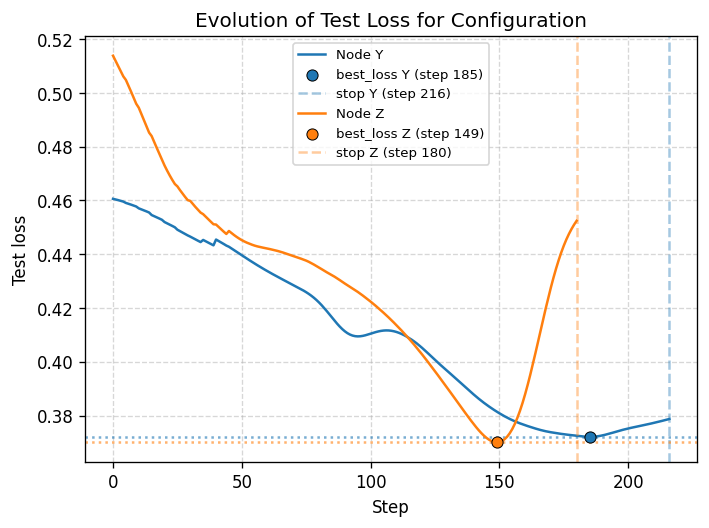

In [ ]:
def plot_test_loss_single_config(training_history, config, nodos=('Y', 'Z'), titulo="Evolution of Test Loss for Configuration"):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    colores = {'Y': 'tab:blue', 'Z': 'tab:orange'}
    for nodo in nodos:
        resultado_nodo = training_history.get(config, {}).get(nodo)
        if resultado_nodo is None:
            continue
        train_results = resultado_nodo.get('train_results')
        if not train_results or 'test_loss' not in train_results:
            continue
        curva = [_a_valor(v) for v in train_results['test_loss']]
        if not curva:
            continue
        color = colores.get(nodo)
        ax.plot(range(len(curva)), curva, label=f"Node {nodo}", color=color)
        best_step = int(np.argmin(curva))
        best_loss = curva[best_step]
        stop_step = len(curva) - 1
        ax.axhline(best_loss, color=color, linestyle=':', alpha=0.6)
        ax.scatter([best_step], [best_loss], color=color, marker='o', zorder=5,
                   s=45, edgecolor='k', linewidths=0.6,
                   label=f"best_loss {nodo} (step {best_step})")
        ax.axvline(stop_step, color=color, linestyle='--', alpha=0.4,
                   label=f"stop {nodo} (step {stop_step})")

    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("Step")
    ax.set_ylabel("Test loss")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_test_loss_single_config(training_history, 'hsic')